# 輪読2026/4/7

## 5章　誤差逆伝播法(p123)

前章ではニューラルネットワークの重みパラメータの勾配に関する計算を数値微分で説明したが時間が非常にかかる.\
誤差逆伝播法はこれらの計算を効率よく行う手法である.\
誤差逆伝播法を正しく理解するには、「数式」と「計算グラフ」からの2つの視点からのアプローチがある.

### 5.1 計算グラフ(p123)
計算グラフとは計算の過程をグラフによってあらわしたもの.\
ここで言うグラフとは,データ構造としてのグラフであり,ノードとエッジから構成される.


#### 5.1.1 計算グラフで解く(p124)
簡単な問題を計算グラフを用いて解いてみる.

例題1:\
太郎くんはスーパーで1コ100円のリンゴを2コ買いました.\
支払う金額を求めなさい.ただし,消費税が10%適用されるものとします.

**例題1の計算グラフ(p124, 図5-1)**

![](5-1_nolabel.svg)

「2」と「100円」と「消費税10%」をノードとして表す.

**例題1の計算グラフ：「リンゴ」と「消費税」を変数とする(p125, 図5-2)**

![](5-2_nolabel.svg)

例題2:\
太郎くんはスーパーで1コ100円のリンゴを2コ,1コ150円のみかんを3コ買いました.\
支払う金額を求めなさい.ただし,消費税が10%適用されるものとします.

**例題2の計算グラフ(p125, 図5-3)**

![](5-3_nolabel.svg)

計算グラフを使って問題を解くには,
* 計算グラフを構築する
* 計算グラフ上で左から右へ進める

「計算を左から右へ進める」　→　順伝播(forward propagation)
「計算を右から左へ進める」　→　逆伝播(backward propagation)


#### 5.1.2 局所的な計算(p126)
計算グラフの特徴は,「局所的な計算」を伝播することによって最終的な結果を得ることができる点にある.\
スーパーでリンゴ2コとそれ以外にたくさんの買い物をする場合を考える.

ポイントは,各ノードにおける計算は局所的な計算であるということ.\
各ノードの計算で行うべきは,自分に寒けする計算だけであり,全体のことは何も気にしなくてよい.

#### 5.1.3 なぜ計算グラフで解くのか(p127)
* 局所的な計算によって,問題を単純化できる
* 途中の計算結果をすべて保持できる
* 逆方向の伝播によって,「微分」を効率的に計算できる
例題1についてリンゴが値上がりした場合,最終的な支払金額にどのような影響があるかを考える.

**逆伝播法による微分値の伝達(p128, 図5-5)**

![](5-5.svg)

$\frac{\partial L}{\partial x}$を求める → 計算グラフ上の逆伝播

### 5.2 連鎖律(p129)
逆方向の伝播が局所的な微分を伝達する原理は,連鎖律によるもの.\

#### 5.2.1 計算グラフの逆伝播(p129)
ここでは,$y = f(x)$について考える.

**計算の逆伝播(p129, 図5-6)**

![](5-6.svg)

#### 5.2.2 連鎖律とは(p129)
連鎖律を説明するうえで,まず合成関数から話を進める.

合成関数：複数の関数によって構成される関数.\
例えば,
$$
\begin{cases}
z = t^2 \\
t = x + y
\end{cases}
\tag{5.1}
$$
連鎖律の定義：\
ある関数が合成関数で表される場合,その合成関数の微分は,合成関数を構成するそれぞれの関数の微分の積によって表される.

式(5.1)の例で考えると式(5.2)のようになる.
$$
\frac{\partial z}{\partial x} = \frac{\partial z}{\partial t} \cdot \frac{\partial t}{\partial x}\
\tag{5.2}
$$
式(5.2)は,ちょうど以下のように打ち消せる.
$$\frac{\partial z}{\color{red}{\partial t}} \cdot \frac{\color{red}{\partial t}}{\partial x} = \frac{\partial z}{\partial x}$$

よって式(5.1)に式(5.2)を適用すると,式(5.3)のようになる.

$$
\begin{cases}
\frac{\partial z}{\partial t} &= 2 \cdot t \\
\frac{\partial t}{\partial x} &= 1 \\
\end{cases}
\tag{5.3}
$$
$$
\begin{aligned}
\frac{\partial z}{\partial x} &= \frac{\partial z}{\partial t} \cdot \frac{\partial t}{\partial x} = 2t \cdot 1 = 2t = 2(x+y)
\end{aligned}
\tag{5.4}
$$

#### 5.2.3 連鎖律と計算グラフ
**式5-4の計算グラフ(p131, 図5-7)**

![](5-7.svg)

計算グラフの逆伝播は、右から左

**(p131, 図5-8)**

![](5-8.svg)

### 5.3 逆伝播(p132)
「$+$」や「$×$」などの演算を例に, 逆伝播の仕組みについて解説.

#### 5.3.1 加算ノードの逆伝播(p132)
$z = x + y$　を対象にして, その逆伝播を見る.

$$
\begin{cases}
\frac{\partial z}{\partial x} &= 1 \\
\frac{\partial z}{\partial y} &= 1
\end{cases}
\tag{5.5}
$$

**加算ノードの逆伝播(p131, 図5-9)**

![](5-9a.svg)
![](5-9b.svg)

上流から伝わった微分に1乗算して下流に流すだけ.
上流から伝わった微分値を$\frac{\partial L}{\partial z}$としたのは, 図5-10が示すように, 最終的に$L$という値を出力する大きなけさんグラフを想定しているため.


**加算ノードの逆伝播の具体例(p133, 図5-11)**

![](5-11a.svg)
![](5-11b.svg)


#### 5.3.2 乗算ノードの逆伝播(p134)
$z = x \cdot y$　を対象にして, その逆伝播を見る.

$$
\begin{cases}
\frac{\partial z}{\partial x} &= y \\
\frac{\partial z}{\partial y} &= x
\end{cases}
\tag{5.6}
$$

**乗算の逆伝播(p134, 図5-12)**

![](5-12a.svg)
![](5-12b.svg)

上流から伝わった値に, 順伝播の際の入力信号を "ひっくり返した値" を乗算して下流に流す.

#### 5.3.3 リンゴの例

例題1を改めて考える.

(再掲)例題1:\
太郎くんはスーパーで1コ100円のリンゴを2コ買いました.\
支払う金額を求めなさい.ただし,消費税が10%適用されるものとします.

「リンゴの値段」・「リンゴの個数」・「消費税」の三つの変数がそれぞれ最終的な料金計算にどのように影響するのか.

**リンゴの買い物の逆伝播の例(p136, 図5-14)**

![](5-14.svg)

リンゴの値段の微分：2.2\
リンゴの個数の微分：110\
消費税の微分：200

例題2についても改めて考える.

(再掲)例題2:\
太郎くんはスーパーで1コ100円のリンゴを2コ, 1コ150円のみかんを3コ買いました.\
支払う金額を求めなさい.ただし,消費税が10%適用されるものとします.

**リンゴとみかんの買い物の逆伝播の例(p136, 図5-15)**

![](5-15.svg)

リンゴの値段の微分：
リンゴの個数の微分：
みかんの値段の微分：

みかんの個数の微分：消費税の微分：

### 5.4 単純なレイヤの実装
「リンゴの買い物」の例をPythonで実装する.

* 乗算ノード → 乗算レイヤ
* 加算ノード → 加算レイヤ

#### 5.4.1 乗算レイヤ
レイヤの共通のメソッド
* forward
* backward

例題１についてこの乗算レイヤを用いて実装する.
計算グラフは図5-16のようになる.

**リンゴ２個の例(p138, 図5-16)**

![](5-16.svg)

In [1]:
# coding: utf-8


class MulLayer:
    def __init__(self):
        self.x = None
        self.y = None

    def forward(self, x, y):
        self.x = x
        self.y = y                
        out = x * y

        return out

    def backward(self, dout):
        dx = dout * self.y
        dy = dout * self.x

        return dx, dy

# リンゴの買い物の例

apple = 100
apple_num = 2
tax = 1.1

mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

# forward
apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)

# backward
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print("price:", int(price))
print("dApple:", dapple)
print("dApple_num:", int(dapple_num))
print("dTax:", dtax)

price: 220
dApple: 2.2
dApple_num: 110
dTax: 200


#### 5.4.2 加算レイヤの実装
例題2について、加算レイヤを実装する.
計算グラフは図5-17のようになる.
**リンゴとみかんの例(p140, 図5-17)**

![](5-17.svg)

In [2]:
class AddLayer:
    def __init__(self):
        pass

    def forward(self, x, y):
        out = x + y

        return out

    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1

        return dx, dy

# リンゴとみかんの買い物の例

apple = 100
apple_num = 2
orange = 150
orange_num = 3
tax = 1.1

# layer
mul_apple_layer = MulLayer()
mul_orange_layer = MulLayer()
add_apple_orange_layer = AddLayer()
mul_tax_layer = MulLayer()

# forward
apple_price = mul_apple_layer.forward(apple, apple_num)  # (1)
orange_price = mul_orange_layer.forward(orange, orange_num)  # (2)
all_price = add_apple_orange_layer.forward(apple_price, orange_price)  # (3)
price = mul_tax_layer.forward(all_price, tax)  # (4)

# backward
dprice = 1
dall_price, dtax = mul_tax_layer.backward(dprice)  # (4)
dapple_price, dorange_price = add_apple_orange_layer.backward(dall_price)  # (3)
dorange, dorange_num = mul_orange_layer.backward(dorange_price)  # (2)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)  # (1)

print("price:", int(price))
print("dApple:", dapple)
print("dApple_num:", int(dapple_num))
print("dOrange:", dorange)
print("dOrange_num:", int(dorange_num))
print("dTax:", dtax)

price: 715
dApple: 2.2
dApple_num: 110
dOrange: 3.3000000000000003
dOrange_num: 165
dTax: 650


### 5.5 活性化関数レイヤの実装
計算グラフの考え方をニューラルネットワークに適用する.
ここではニューラルネットワークを構成する「層（レイヤ）」を1つのクラスとして実装する.
まずはReLUとSigmoidレイヤを実装する.

#### 5.5.1 ReLUレイヤ
活性化関数として扱われるReLU（Rectfied Linear Unit）は次の式で表される.
$$
y =
\begin{cases}
x & (x > 0) \\
0 & (x \leq 0)
\end{cases}
\tag{5.7}
$$

式（5.7）からxに関するyの微分は（5.8）のようになる.
$$
\frac{\partial y}{\partial x} =
\begin{cases}
1 & (x > 0) \\
0 & (x \leq 0)
\end{cases}
\tag{5.8}
$$

計算グラフに表すと図5-18のようになる.

**図5-18：ReLUレイヤの計算グラフ(p142, 図5-18)**

![](5-18a.svg)
![](5-18b.svg)

PythonでReLUレイヤを実装する.

In [3]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir) # ＋親ディレクトリ
import numpy as np
import numpy as np
from common.functions import *
from common.util import im2col, col2im


class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [4]:
x = np.array([[1.0, -0.5], [-2.0, 3.0]])
print(x)

[[ 1.  -0.5]
 [-2.   3. ]]


In [5]:
mask = (x <= 0)
print(mask)

[[False  True]
 [ True False]]


#### 5.5.2 Sigmoidレイヤ
活性化関数として扱われるSigmoidは次の式で表される.
$$
y = \frac{1}{1 + \exp(-x)}
\tag{5.9}
$$

式（5.9）を計算グラフにあらわすと図5-19のようになる.

**Sigmoidレイヤの計算グラフ(p143, 図5-19)**

![](5-19.svg)


逆伝播
* ステップ1
「$/$」ノードは$y = \frac{1}{x}$を表すので, 逆伝播は式（5.10）になる.
$$
\frac{\partial y}{\partial x} = -\frac{1}{x^2}
= -y^2
\tag{5.10}
$$
よって逆伝播の時は, 上流の値に対して, $-y^2$を乗算して下流に流す.

* ステップ2
「$+$」ノードは上流の値を下流にそのまま流すだけ.

* ステップ3
「$\exp$」ノードは$y = \exp(x)$を表すので, 逆伝播は式（5.11）になる.
$$
\frac{\partial y}{\partial x} = \exp(x)
\tag{5.11}
$$
よって逆伝播の時は, 上流の値に対して, $\exp(x)$を乗算して下流に流す.

* ステップ4
「$×$」ノードは順伝播時の値をひっくり返して乗算.
そのためここでは$-1$を乗算する.

**Sigmoidレイヤの計算グラフ(p144, 図5-20)**

![](5-20.svg)

$\frac{\partial L}{\partial y}y^2\exp(-x)$は順伝播の入力$x$と出力$y$だけから計算できる.
よって計算グラフにおいては１つにグループ化した「Sigmoid」ノードとして書くことができる.

**Sigmoidレイヤの計算グラフ(簡略版)(p145, 図5-21)**

![](5-21.svg)

また$\frac{\partial L}{\partial y}y^2\exp(-x)$は以下のように書き換えられる.

$$
\begin{aligned}
\frac{\partial L}{\partial y}y^2\exp(-x) &= \frac{\partial L}{\partial y} \cdot \frac{1}{(1 + \exp(-x))^2} \cdot \exp(-x) \\
&= \frac{\partial L}{\partial y} \cdot \frac{1}{1 + \exp(-x)} \cdot \frac{\exp(-x)}{1 + \exp(-x)} \\
&= \frac{\partial L}{\partial y} \cdot y \cdot (1 - y)
\tag{5.12}
\end{aligned}\\
$$

そのためSigmoidレイヤの逆伝播は, 順伝播の出力だけから計算できる.

SigmoidレイヤをPythonで実装する.

In [6]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = sigmoid(x)
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

### 5.6 Affineレイヤ / Softmaxレイヤの実装

#### 5.6.1 Affineレイヤ
ニューラルネットワークの順伝播は, で行う行列の積を「アフィン変換」と呼び, アフィン変換を行う処理を「Affineレイヤ」という名前で実装していく.

In [7]:
X = np.random.rand(2)
W = np.random.rand(2, 3)
B = np.random.rand(3)

print(X.shape)
print(W.shape)
print(B.shape)

(2,)
(2, 3)
(3,)


この計算を計算グラフであらわす.
行列の計算を行うノードを「dot」ノードと呼ぶ.

**Affineレイヤの計算グラフ(p148, 図5-24)**

![](5-24.svg)

スカラ値の時と同じ手順で逆伝播を行う.
$$
\begin{aligned}
\frac{\partial L}{\partial X} &= \frac{\partial L}{\partial Y} \cdot W^T \\
\frac{\partial L}{\partial W} &= X^T \cdot \frac{\partial L}{\partial Y} \\
\end{aligned}
\tag{5.13}
$$

$$
W = 
\begin{pmatrix}
w_{11} & w_{12} & w_{13} \\
w_{21} & w_{22} & w_{23}
\end{pmatrix}\\

W^T =
\begin{pmatrix}
w_{11} & w_{21} \\
w_{12} & w_{22} \\
w_{13} & w_{23}
\end{pmatrix}
\tag{5.14}
$$

$W$の形状は(2, 3)であるため, $W^T$の形状は(3, 2)になる.

**「dot」ノードの逆伝播(p150, 図5-26)**

![](5-26.png)

#### 5.6.2 バッチ版 Affineレイヤ
N個のデータをまとめて順伝播する場合, つまりバッチ版のAffineレイヤを考える.

**バッチ版のAffineレイヤの計算グラフ(p150, 図5-26)**

![](5-27.svg)

これまでとの違いはXの形状が(N, 2)になっている点.

バイアスの$B$は$X\cdot W$のそれぞれのデータに加算される.

N = 2の場合について以下で考える.

In [8]:
X_dot_W = np.array([[0, 0, 0], [10, 10, 10]])
B = np.array([1, 2, 3])

In [9]:
print(X_dot_W)

[[ 0  0  0]
 [10 10 10]]


In [10]:
print(X_dot_W + B)

[[ 1  2  3]
 [11 12 13]]


逆伝播の場合は, それぞれのデータの逆伝播の値がバイアスの要素に集約される必要がある.

In [11]:
dY = np.array([[1, 2, 3], [4, 5, 6]])
print(f'dY = {dY}')
dB = np.sum(dY, axis=0)
print(f'dB = {dB}')

dY = [[1 2 3]
 [4 5 6]]
dB = [5 7 9]


これらからAffineレイヤをPythonで実装する.

In [12]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        return dx
# N = 3の場合

X = np.array([[1, 1], [2, 2], [3, 3]])
W = np.array([[1, 1, 1], [10, 10, 10]])
B = np.array([1, 2, 3])
print(f'X-> {np.shape(X)}')
print(f'W-> {np.shape(W)}')
print(f'B-> {np.shape(B)}')

Affine_layer = Affine(W, B)

Y = Affine_layer.forward(X)
print(f'Y-> {np.shape(Y)}')
print(Y)



X-> (3, 2)
W-> (2, 3)
B-> (3,)
Y-> (3, 3)
[[12 13 14]
 [23 24 25]
 [34 35 36]]


#### 5.6.3 Softmax-with-Lossレイヤ
ソフトマックス関数は入力された値を正規化して出力する.
手書き数字認識は, 10クラス分類を行うため, Softmaxレイヤへの入力は10個

ニューラルネットワークにおける処理は「推論」と「学習」の2つに分けられる.
* スコア：正規化しない出力結果
* 確率：正規化された出力結果

推論においては, スコアの最大値にのみ興味があるため、わざわざ計算コストをかけて正規化する必要はない.

学習においては, 確率から交差エントロピー誤差のような目的関数に落とし込みパラメタ更新につなげていく必要がある.

-> 確率（正規化された値）が必要になるため, ソフトマックス関数を用いる.

**「簡易版Softmax-with-Lossレイヤ」の計算グラフ(p154, 図5-30)**

<img src="5-30.svg" width="400px" />

計算グラフの考察
* 順伝播：$(y_1, y_2, y_3)$ はSoftmaxレイヤの出力、$(t_1, t_2, t_3)$ は教師ラベル
* 逆伝播：$(y_1 - t_1, y_2 - t_2, y_3 - t_3)$
* ニューラルネットワークの逆伝播では、この差分（誤差）が新しいいて伝わっていく。
* もともと、Cross Entropy Error はこうなるように設計された関数。
  回帰問題では、出力層に「恒等関数」を用い、損失関数として「二乗和誤差」を用いるが、これら同様の理由による。

以下でSoftmax-with-LossレイヤをPythonで実装する.

In [13]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None # softmaxの出力
        self.t = None # 教師データ

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        
        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size: # 教師データがone-hot-vectorの場合
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size
        
        return dx

### 5.7 誤差逆伝播法の実装
ここまでで実装してきたレイヤを組み合わることでニューラルネットワークを構築することができる.

#### 5.7.1 ニューラルネットワークの学習の全体図
前提\
ニューラルネットワークには「重み」と「バイアス」がある.\
この重みとバイアスを訓練データに適応するように調整することを「学習」と呼ぶ.

学習の手順
1. ミニバッチ\
訓練データの中からランダムに一部のデータを選び出す.

2. 勾配の算出\
各重みパラメータに関する損失関数の勾配を求める.
(4章：数値微分, 5章：誤差逆伝播法)

3. パラメータの更新\
重みパラメータを勾配方向に微小量だけ更新する.

4. 繰り返す\
1~3の手順を繰り返す.

#### 5.7.2 逆誤差伝播法に対応したニューラルネットワークの実装
実装の際にニューラルネットワークのレイヤを「OrderedDict」として保持する.

OrderedDictとは
* 辞書に追加した要素の順番を記憶しておくことができる\
　→ 順伝播：追加した順番でレイヤを呼び出す.\
　→ 逆伝播：追加した順番の逆でレイヤを呼び出す.\
* レイヤを正しい準パンで連結し, 順番に呼び出すだけでよい.

レイヤ
* ニューラルネットワーク構成要素を「レイヤ」としてモジュール化する.
* どんなにニューラルネットワークの層が増えても, レイヤを追加するだけで済む.

実際にPythonで実装する.
　

In [14]:

import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from common.layers import *
from common.gradient import numerical_gradient
from collections import OrderedDict


class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size) 
        self.params['b2'] = np.zeros(output_size)

        # レイヤの生成
        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

        self.lastLayer = SoftmaxWithLoss()
        
    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        
        return x
        
    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
        
    # x:入力データ, t:教師データ
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)
        
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        
        return grads
        
    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.lastLayer.backward(dout)
        
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W2'], grads['b2'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads


#### 5.7.3 誤差逆伝播法の勾配確認
* 誤差逆伝播法\
　計算が早いため, 大量のパラメータが存在しても効率的に勾配を求めることができる.\
　しかし, 実装が複雑になるため, ミスが起きやすい.
* 数値微分\
　計算に時間がかかるが, 実装が簡単であり, ミスが起きにくい.

誤差逆伝播法による勾配計算が正しく実装されているかを確認するために, 数値微分による勾配計算と比較する方法がある.\
これを「勾配確認」と呼ぶ.

Pythonで勾配確認を実装する.

In [15]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from dataset.mnist import load_mnist
from ch05.two_layer_net import TwoLayerNet

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

x_batch = x_train[:3]
t_batch = t_train[:3]

grad_numerical = network.numerical_gradient(x_batch, t_batch)
grad_backprop = network.gradient(x_batch, t_batch)

for key in grad_numerical.keys():
    diff = np.average( np.abs(grad_backprop[key] - grad_numerical[key]) )
    print(key + ":" + str(diff))

W1:3.8733617396185106e-10
b1:2.1212303740933933e-09
W2:6.5031033560362325e-09
b2:1.4006248770792596e-07


上記の実行結果は, 誤差逆伝播法による勾配計算と数値微分による勾配計算による値の差が1e-9~1e-10程度であることを示している.\
この程度の差であれば, 誤差逆伝播法による勾配計算は正しく実装されていると判断できる.

#### 5.7.4 誤差逆伝播法の学習
誤差逆伝播法を使ったニューラルネットワークの学習をPythonで実装する.

In [ ]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)

import numpy as np
from dataset.mnist import load_mnist
from ch05.two_layer_net import TwoLayerNet

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
print(x_train.shape)
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
print("iter:train_acc, test_acc")
for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 勾配
    #grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)
    
    # 更新
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        
        print(f'{i:4d}:{train_acc:5f}, {test_acc:5f}')# グラフで確認
import matplotlib.pyplot as plt

epochs= np.arange(len(train_acc_list)) # 0, 1, ...



(60000, 784)
iter:train_acc, test_acc
   0:0.115717, 0.115200
 600:0.901750, 0.905400
1200:0.921633, 0.924800
1800:0.936700, 0.936100
2400:0.944500, 0.944100
3000:0.952517, 0.950200
3600:0.956817, 0.951700
4200:0.961617, 0.957200
4800:0.964500, 0.960500
5400:0.967300, 0.959700
6000:0.970000, 0.964900
6600:0.972417, 0.966200
7200:0.974383, 0.969800
7800:0.974200, 0.967600
8400:0.975617, 0.968400
9000:0.977167, 0.969900


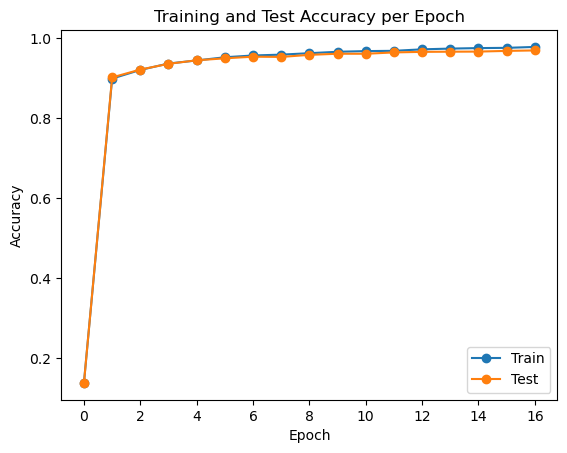

In [17]:
# グラフで確認
import matplotlib.pyplot as plt

epochs= np.arange(len(train_acc_list)) # 0, 1, ...

plt.figure()
plt.plot(epochs, train_acc_list, marker='o')
plt.plot(epochs, test_acc_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy per Epoch")
plt.legend(["Train", "Test"])
plt.show()

実行結果
* 1エポック後には訓練制度が90%以上となっている
* 5~6エポック後には95%以上
* 最終的に両者ともに97%程度に落ち着いている

### 5.8 まとめ
* 計算グラフを用いると計算の過程を可視化できる
* 計算グラフのノードは局所的な計算によって構成される
* 計算グラフの順伝播は, 通常の計算を行う.一方, 計算グラフに順伝播によって, 各ノードの微分を求めることができる
* ニューラルネットワークの構成要素をレイヤとして実装することで, 勾配の計算を効率的に求めることができる
* 数値微分と誤差逆伝播法の結果を比較することで, 誤差逆伝播法の実装に誤りがないことを確認できる（勾配確認）